In [2]:
!pip install pandas scikit-learn matplotlib seaborn



In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
url = "https://raw.githubusercontent.com/AREEG94FAHAD/TaskComplexityEval-24/main/problems_data.jsonl"

df = pd.read_json(url, lines=True)


: 

In [6]:
df.head()


,title,description,input_description,output_description,sample_io,problem_class,problem_score,url
0,Uuu,Unununium (Uuu) was the name of the chemical\n...,The input consists of one line with two intege...,The output consists of $M$ lines where the $i$...,"[{'input': '7 10', 'output': '1 2 2 3 1 3 3 4 ...",hard,9.7,https://open.kattis.com/problems/uuu
1,House Building,A number of eccentrics from central New York h...,"The input consists of $10$ test cases, which a...",Print $K$ lines with\n the positions of the...,"[{'input': '0 2 3 2 50 60 50 30 50 40', 'outpu...",hard,9.7,https://open.kattis.com/problems/husbygge
2,Mario or Luigi,Mario and Luigi are playing a game where they ...,,,"[{'input': '', 'output': ''}]",hard,9.6,https://open.kattis.com/problems/marioorluigi
3,The Wire Ghost,Žofka is bending a copper wire. She starts wit...,The first line contains two integers $L$ and $...,The output consists of a single line consistin...,"[{'input': '4 3 3 C 2 C 1 C', 'output': 'GHOST...",hard,9.6,https://open.kattis.com/problems/thewireghost
4,Barking Up The Wrong Tree,"Your dog Spot is let loose in the park. Well, ...",The first line of input consists of two intege...,Write a single line containing the length need...,"[{'input': '2 0 10 0 10 10', 'output': '14.14'...",hard,9.6,https://open.kattis.com/problems/barktree


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4112 entries, 0 to 4111
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               4112 non-null   object 
 1   description         4112 non-null   object 
 2   input_description   4112 non-null   object 
 3   output_description  4112 non-null   object 
 4   sample_io           4112 non-null   object 
 5   problem_class       4112 non-null   object 
 6   problem_score       4112 non-null   float64
 7   url                 4112 non-null   object 
dtypes: float64(1), object(7)
memory usage: 257.1+ KB


In [8]:
df.isnull().sum()


title                 0
description           0
input_description     0
output_description    0
sample_io             0
problem_class         0
problem_score         0
url                   0
dtype: int64

In [9]:
text_columns = ['description', 'input_description', 'output_description']

for col in text_columns:
    df[col] = df[col].fillna("")


In [10]:
df['combined_text'] = (
    df['description'] + " " +
    df['input_description'] + " " +
    df['output_description']
)


In [11]:
df[['combined_text', 'problem_class', 'problem_score']].head()


,combined_text,problem_class,problem_score
0,Unununium (Uuu) was the name of the chemical\n...,hard,9.7
1,A number of eccentrics from central New York h...,hard,9.7
2,Mario and Luigi are playing a game where they ...,hard,9.6
3,Žofka is bending a copper wire. She starts wit...,hard,9.6
4,"Your dog Spot is let loose in the park. Well, ...",hard,9.6


In [12]:
X = df['combined_text']
y_class = df['problem_class']
y_score = df['problem_score']


In [13]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(X)


In [14]:
X_train, X_test, y_class_train, y_class_test = train_test_split(
    X_tfidf, y_class, test_size=0.2, random_state=42
)

_, _, y_score_train, y_score_test = train_test_split(
    X_tfidf, y_score, test_size=0.2, random_state=42
)


In [15]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_class_train)


LogisticRegression(max_iter=1000)

In [16]:
y_pred_class = clf.predict(X_test)


In [17]:
accuracy_score(y_class_test, y_pred_class)


0.5078979343863913

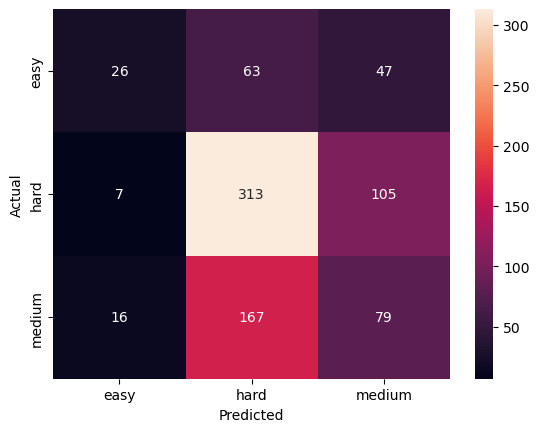

In [18]:
cm = confusion_matrix(y_class_test, y_pred_class)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [19]:
reg = LinearRegression()
reg.fit(X_train, y_score_train)


LinearRegression()

In [20]:
y_pred_score = reg.predict(X_test)


In [22]:
mae = mean_absolute_error(y_score_test, y_pred_score)

mse = mean_squared_error(y_score_test, y_pred_score)
rmse = np.sqrt(mse)

mae, rmse



(3.69918641315844, np.float64(4.706225645532768))

In [23]:
new_problem = """
Given an array of integers, find the maximum subarray sum.
Input: n followed by n integers.
Output: maximum sum.
"""

new_vec = tfidf.transform([new_problem])

pred_class = clf.predict(new_vec)[0]
pred_score = reg.predict(new_vec)[0]

pred_class, pred_score


('medium', np.float64(5.812286373755617))

In [24]:
import pickle

# Save models
with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("clf_model.pkl", "wb") as f:
    pickle.dump(clf, f)

with open("reg_model.pkl", "wb") as f:
    pickle.dump(reg, f)
